In [1]:
# imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import warnings
warnings.filterwarnings('ignore')

2026-02-27 17:50:19.818959: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772214620.011175      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772214620.068446      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772214620.534368      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772214620.534417      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772214620.534421      55 computation_placer.cc:177] computation placer alr

In [3]:
# load data

df = pd.read_csv('/kaggle/input/datasets/varpit94/tesla-stock-data-updated-till-28jun2021/TSLA.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (2956, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [5]:
# basic info about data

print(df.dtypes)
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\n{df.describe()}")

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

              Open         High          Low        Close    Adj Close  \
count  2956.000000  2956.000000  2956.000000  2956.000000  2956.000000   
mean    138.691296   141.771603   135.425953   138.762183   138.762183   
std     250.044839   255.863239   243.774157   250.123115   250.123115   
min       3.228000     3.326000     2.996000     3.160000     3.160000   
25%      19.627000    20.402000    19.127500    19.615000    19.615000   
50%      46.656999    47.487001    45.820002    46.545000    46.545000   
75%      68.057001    69.357500    66.911501    68.103998    68.103998   
max    1234.410034  1243.489990  1217.000000  1229.910034  1229.910034   

             Volume  
count  2.95600

In [6]:
# cleaning and preparing

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Records: {len(df)}")
print(f"Period: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Price range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")

Records: 2956
Period: 2010-06-29 to 2022-03-24
Price range: $3.16 - $1229.91


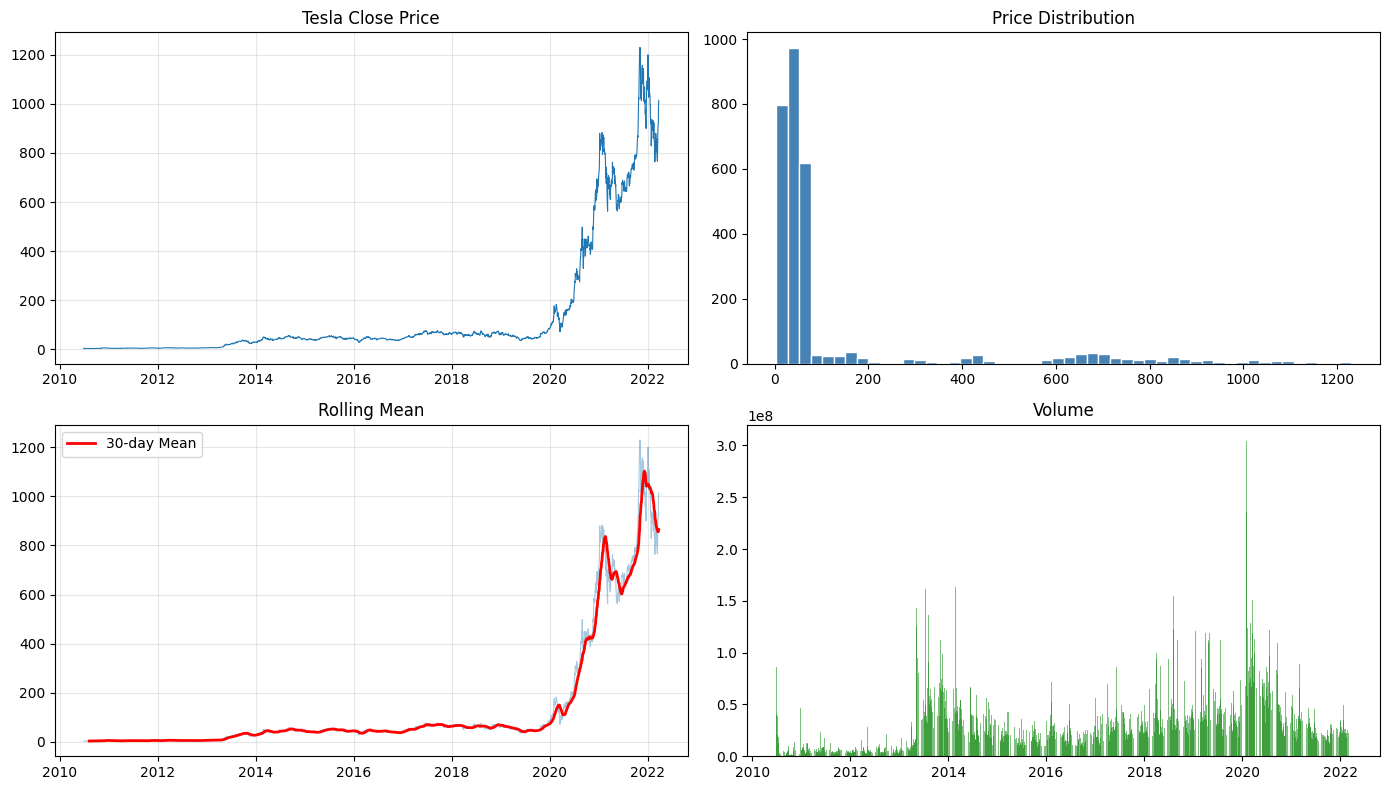

In [7]:
# visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(df['Date'], df['Close'], linewidth=0.8)
axes[0,0].set_title('Tesla Close Price')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df['Close'], bins=50, color='steelblue', edgecolor='white')
axes[0,1].set_title('Price Distribution')

# Rolling stats
rm = df['Close'].rolling(30).mean()
axes[1,0].plot(df['Date'], df['Close'], alpha=0.4, linewidth=0.8)
axes[1,0].plot(df['Date'], rm, color='red', linewidth=2, label='30-day Mean')
axes[1,0].set_title('Rolling Mean')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].bar(df['Date'], df['Volume'], color='green', alpha=0.5, width=2)
axes[1,1].set_title('Volume')

plt.tight_layout()
plt.show()

In [8]:
# adf test to check stationarity

values = df['Close'].values

# Test original
adf = adfuller(values, autolag='AIC')
print(f"Original — ADF Stat: {adf[0]:.4f}, P-value: {adf[1]:.6f}")
print("Stationary" if adf[1] < 0.05 else "NOT Stationary")

# Test after differencing
values_diff = np.diff(values)
adf2 = adfuller(values_diff, autolag='AIC')
print(f"\nDifferenced — ADF Stat: {adf2[0]:.4f}, P-value: {adf2[1]:.6f}")
print("Stationary" if adf2[1] < 0.05 else "NOT Stationary")

USE_DIFF = adf[1] >= 0.05
print(f"\nUsing differencing: {USE_DIFF}")

Original — ADF Stat: 1.4239, P-value: 0.997220
NOT Stationary

Differenced — ADF Stat: -9.8450, P-value: 0.000000
Stationary

Using differencing: True


In [9]:
# scaling and creating Windows

LOOK_BACK = 60
raw_values = values.copy()

# Differencing if needed
model_data = np.diff(values) if USE_DIFF else values.copy()

# Scale to [0,1]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(model_data.reshape(-1, 1))

# Sliding windows
X, y = [], []
for i in range(LOOK_BACK, len(scaled)):
    X.append(scaled[i-LOOK_BACK:i, 0])
    y.append(scaled[i, 0])

X = np.array(X).reshape(-1, LOOK_BACK, 1)
y = np.array(y)

print(f"X: {X.shape}, y: {y.shape}")

X: (2895, 60, 1), y: (2895,)


In [10]:
# Splitting Data in train and test set

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 2316, Test: 579


In [11]:
# building Stacked LSTM model structure

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

I0000 00:00:1772214756.932340      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# training the model

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

print(f"\nEpochs trained: {len(history.history['loss'])}")

Epoch 1/100


I0000 00:00:1772214771.397036     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0398 - val_loss: 8.7209e-05
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 4.8881e-05
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0015 - val_loss: 6.8848e-05
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - val_loss: 4.0268e-05
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 4.4196e-05
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 4.8615e-05
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 4.0777e-05
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 3.7168e-05
Epoch 9/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 4.8410e-05
Epoch 10/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 9.7626e-04 - val_loss: 8.5914e-05
Epoch 11/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0010 - val_loss: 4.2555e-05
Epoch 12/100
66/

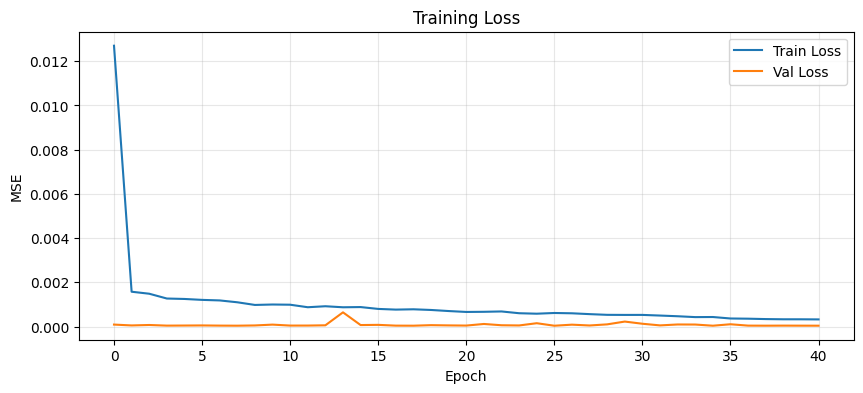

In [13]:
# loss curves

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# prediction and evaluation

# Predict
pred_scaled = model.predict(X_test, verbose=0)
pred_inv = scaler.inverse_transform(pred_scaled).flatten()
actual_inv = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Undo differencing
if USE_DIFF:
    test_start = split + LOOK_BACK + 1
    base = raw_values[test_start-1 : test_start-1+len(pred_inv)]
    pred_final = base + pred_inv
    actual_final = raw_values[test_start : test_start+len(pred_inv)]
    min_len = min(len(actual_final), len(pred_final))
    actual_final, pred_final = actual_final[:min_len], pred_final[:min_len]
else:
    actual_final, pred_final = actual_inv, pred_inv

# Metrics
rmse = np.sqrt(mean_squared_error(actual_final, pred_final))
mae = mean_absolute_error(actual_final, pred_final)
mape = np.mean(np.abs((actual_final - pred_final) / (np.abs(actual_final) + 1e-8))) * 100
accuracy = 100 - mape

print(f"RMSE:     ${rmse:.2f}")
print(f"MAE:      ${mae:.2f}")
print(f"MAPE:     {mape:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

RMSE:     $25.25
MAE:      $16.50
MAPE:     3.22%
Accuracy: 96.78%


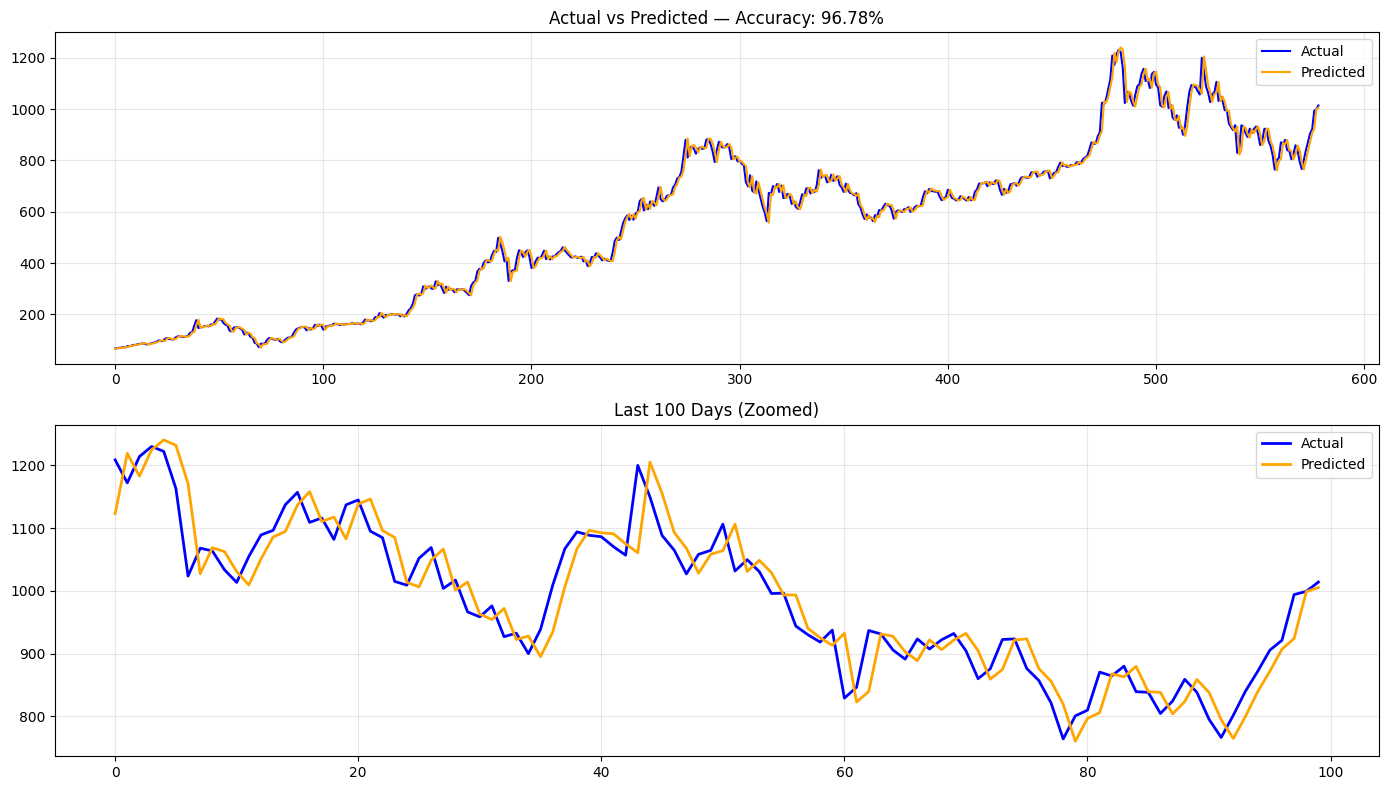

In [15]:
# visualization

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(actual_final, label='Actual', color='blue', linewidth=1.5)
axes[0].plot(pred_final, label='Predicted', color='orange', linewidth=1.5)
axes[0].set_title(f'Actual vs Predicted — Accuracy: {accuracy:.2f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed last 100
z = min(100, len(actual_final))
axes[1].plot(actual_final[-z:], label='Actual', color='blue', linewidth=2)
axes[1].plot(pred_final[-z:], label='Predicted', color='orange', linewidth=2)
axes[1].set_title(f'Last {z} Days (Zoomed)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

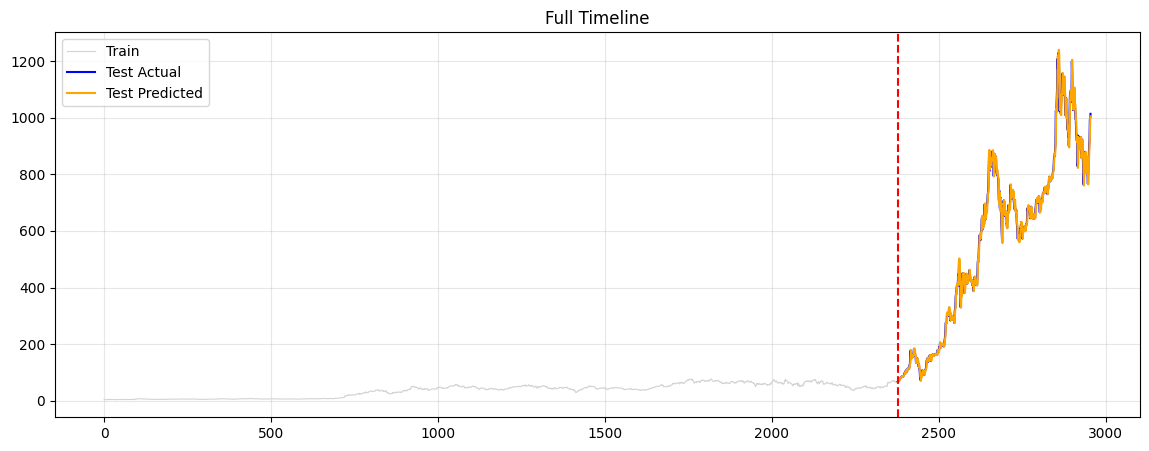

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(raw_values, color='lightgray', linewidth=0.8, label='Train')

t_range = range(len(raw_values)-len(actual_final), len(raw_values))
plt.plot(t_range, actual_final, color='blue', linewidth=1.5, label='Test Actual')
plt.plot(t_range, pred_final, color='orange', linewidth=1.5, label='Test Predicted')
plt.axvline(x=len(raw_values)-len(actual_final), color='red', linestyle='--')

plt.title('Full Timeline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Saving model and configuration for streamlit

model.save('/kaggle/working/lstm_model.h5')
joblib.dump(scaler, '/kaggle/working/scaler.pkl')
joblib.dump({
    'look_back': LOOK_BACK,
    'use_differencing': USE_DIFF,
    'rmse': float(rmse),
    'mae': float(mae),
    'accuracy': float(accuracy),
    'trained_on': 'Tesla (TSLA)'
}, '/kaggle/working/config.pkl')

print("Saved: lstm_model.h5, scaler.pkl, config.pkl")
print("Download from OUTPUT tab →")

Saved: lstm_model.h5, scaler.pkl, config.pkl
Download from OUTPUT tab →
